In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Which positions command the highest market values?
df_latest_market_value=pd.read_csv("player_latest_market_value/player_latest_market_value.csv")
df_latest_market_value.head()

,player_id,date_unix,value
0,1,2009-04-22,0.0
1,6,2010-08-01,0.0
2,8,2010-01-01,0.0
3,10,2016-06-30,0.0
4,11,2009-03-18,0.0


In [22]:
df_player_profiles=pd.read_csv("player_profiles/player_profiles.csv")
df_player_profiles.head()

C:\Users\laura\AppData\Local\Temp\ipykernel_48472\3987506534.py:1: DtypeWarning: Columns (0: third_club_url, 1: third_club_name, 2: fourth_club_url, 3: fourth_club_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df_player_profiles=pd.read_csv("player_profiles/player_profiles.csv")


,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,...,on_loan_from_club_id,on_loan_from_club_name,contract_there_expires,second_club_url,second_club_name,third_club_url,third_club_name,fourth_club_url,fourth_club_name,date_of_death
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_player_profiles.columns


Index(['player_id', 'player_slug', 'player_name', 'player_image_url',
       'name_in_home_country', 'date_of_birth', 'place_of_birth',
       'country_of_birth', 'height', 'citizenship', 'is_eu', 'position',
       'main_position', 'foot', 'current_club_id', 'current_club_name',
       'joined', 'contract_expires', 'outfitter', 'social_media_url',
       'player_agent_id', 'player_agent_name', 'contract_option',
       'date_of_last_contract_extension', 'on_loan_from_club_id',
       'on_loan_from_club_name', 'contract_there_expires', 'second_club_url',
       'second_club_name', 'third_club_url', 'third_club_name',
       'fourth_club_url', 'fourth_club_name', 'date_of_death'],
      dtype='str')

In [24]:
cols = ['player_id', 'position', 'main_position', 'foot']
df_pp = df_player_profiles[cols].copy()
df = df_latest_market_value.merge(df_pp, on='player_id', how='inner')

In [43]:
df = df[df['value'].notna() & (df['value'] > 0)]
df = df[df['position'].notna()     & (df['position']      != '')]
df = df[df['main_position'].notna() & (df['main_position'] != '')]
df = df[df['foot'].notna()          & (df['foot']          != '')]
df = df[(df['main_position'] != df['position']) | (df['main_position'] == 'Goalkeeper')]
df = df[df['date_unix'].notna()]

In [44]:
df['value_year'] = pd.to_datetime(df['date_unix'], unit='s').dt.year

In [45]:
df['value_m'] = df['value'] / 1_000_000

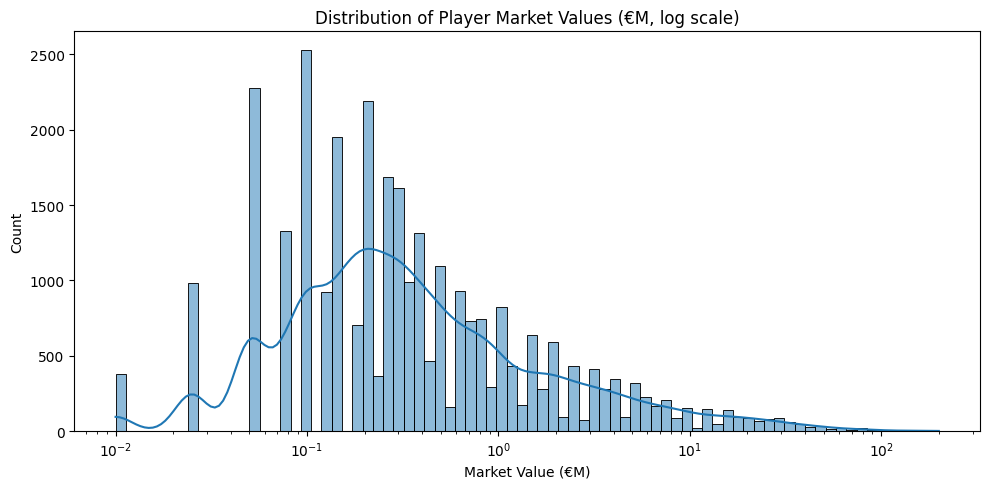

In [46]:
plt.figure(figsize=(10, 5))
sns.histplot(df['value_m'], bins=80, log_scale=True, kde=True)
plt.title("Distribution of Player Market Values (€M, log scale)")
plt.xlabel("Market Value (€M)")
plt.tight_layout()
plt.savefig("eda_value_distribution.png")
plt.show()

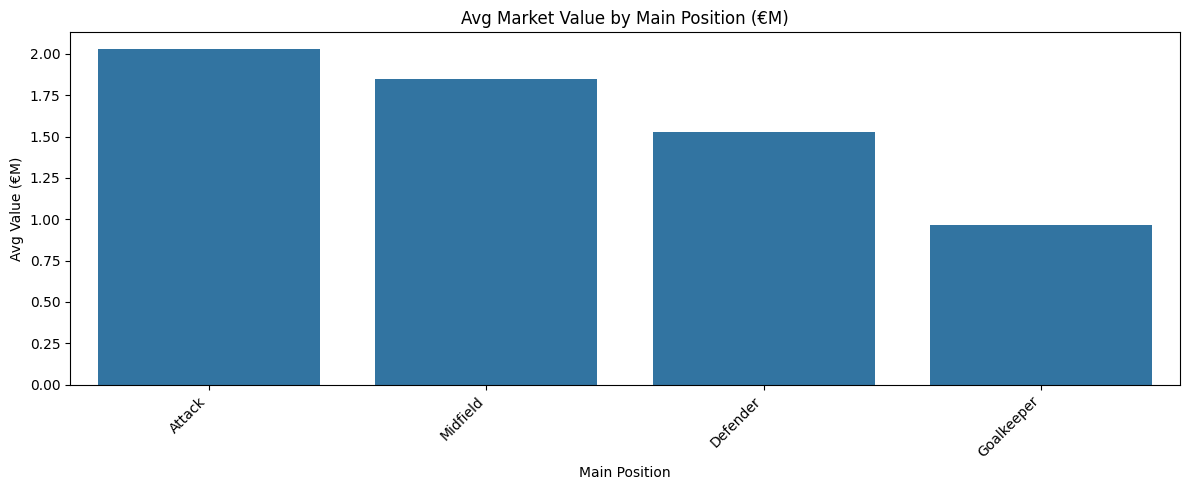

In [47]:
main_pos_avg = (df.groupby('main_position')['value_m']
             .mean()
             .sort_values(ascending=False)
             .reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(data=main_pos_avg, x='main_position', y='value_m')
plt.xticks(rotation=45, ha='right')
plt.title("Avg Market Value by Main Position (€M)")
plt.xlabel("Main Position")
plt.ylabel("Avg Value (€M)")
plt.tight_layout()
plt.savefig("eda_value_by_main_position.png")
plt.show()

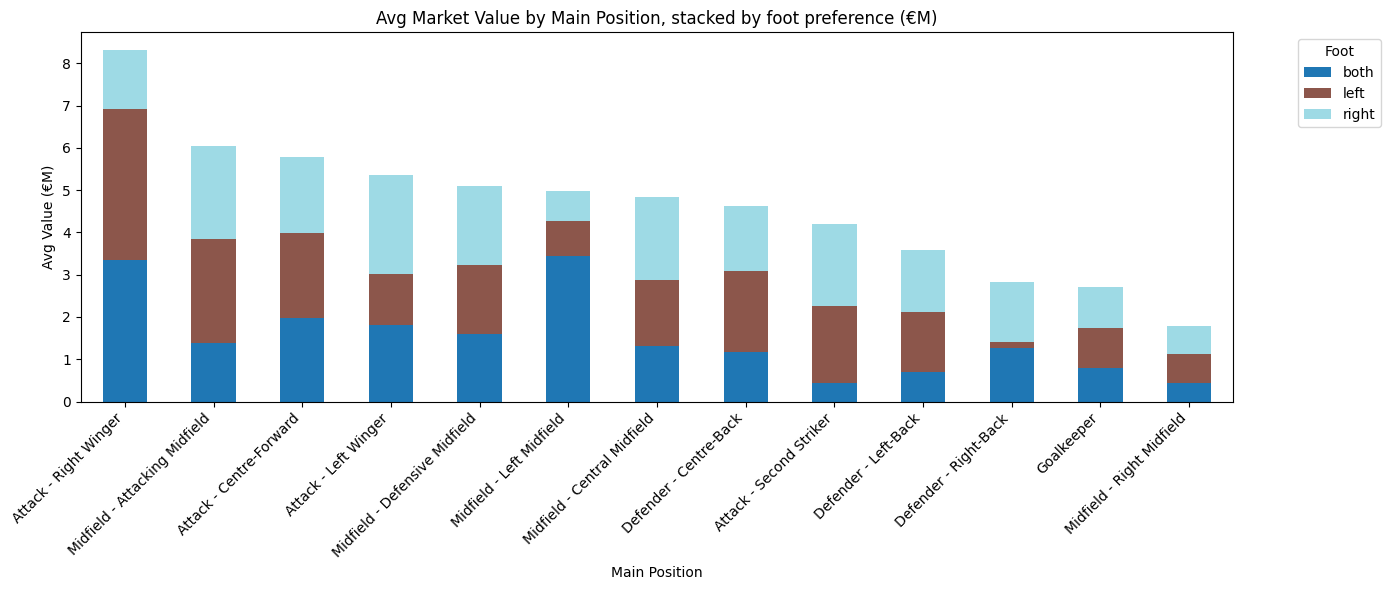

In [50]:
foot_pr_main_pos = (df.groupby(['position', 'foot'])['value_m']
             .mean()
             .reset_index())

pivot = foot_pr_main_pos.pivot(index='position', columns='foot', values='value_m').fillna(0)

# Sort by total avg value descending
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.xticks(rotation=45, ha='right')
plt.title("Avg Market Value by Main Position, stacked by foot preference (€M)")
plt.xlabel("Main Position")
plt.ylabel("Avg Value (€M)")
plt.legend(title="Foot", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("market_value_by_foot_position.png")
plt.show()

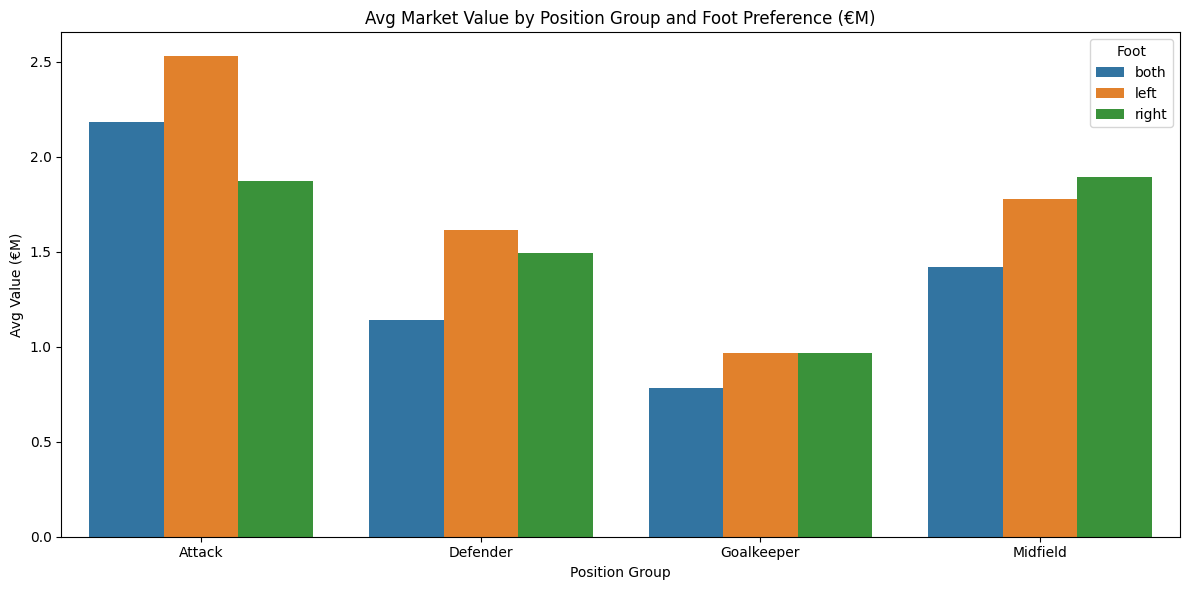

In [52]:
pos_foot = (df.groupby(['main_position', 'foot'])['value_m']
              .mean()
              .reset_index())

plt.figure(figsize=(12, 6))
sns.barplot(data=pos_foot, x='main_position', y='value_m', hue='foot', palette='tab10')

plt.title("Avg Market Value by Position Group and Foot Preference (€M)")
plt.xlabel("Position Group")
plt.ylabel("Avg Value (€M)")
plt.legend(title="Foot")
plt.tight_layout()
plt.savefig("eda_value_main_position_foot.png")
plt.show()

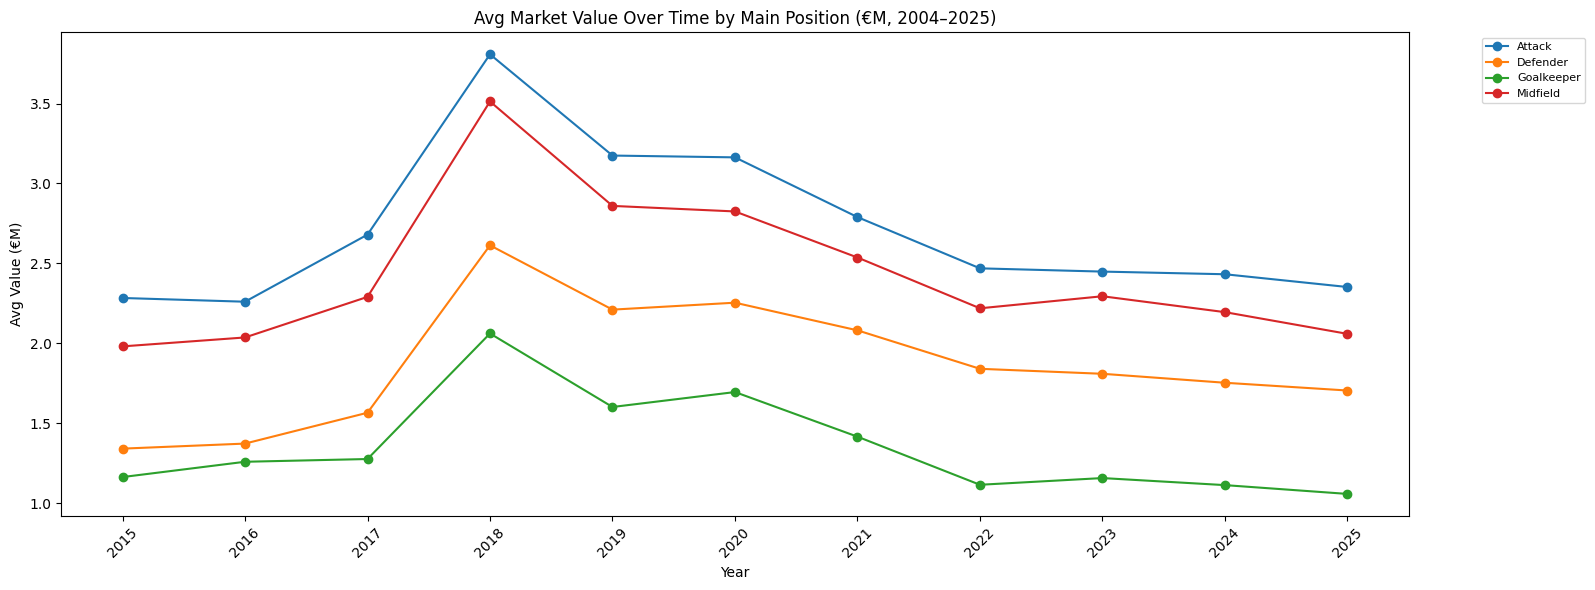

In [62]:
time_pos = (df_hist[df_hist['value_year'].isin(valid_years) & (df_hist['value_year'] >= 2015)]
              .groupby(['value_year', 'main_position'])['value_m']
              .mean()
              .reset_index())

pivot = time_pos.pivot(index='value_year', columns='main_position', values='value_m')

fig, ax = plt.subplots(figsize=(16, 6))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', label=col)

ax.set_xticks(pivot.index)
ax.set_xticklabels(pivot.index, rotation=45)
ax.set_title("Avg Market Value Over Time by Main Position (€M, 2004–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Avg Value (€M)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("eda_value_over_time_main_position.png")
plt.show()



In [45]:
df_transfers   = pd.read_csv("transfer_history/transfer_history.csv")
df_market_hist = pd.read_csv("player_market_value/player_market_value.csv")

In [46]:
print(df_market_hist.columns.tolist())
print(df_market_hist.head())

['player_id', 'date_unix', 'value']
   player_id   date_unix       value
0    1000135  2023-12-19    100000.0
1    1000135  2024-06-23    100000.0
2         10  2005-01-06   9000000.0
3         10  2008-06-03  20000000.0
4         10  2009-08-29  12000000.0


In [42]:
#Prep transfer fees by season
df_fees = df_transfers[df_transfers['transfer_fee'].notna() & (df_transfers['transfer_fee'] > 0)]
fee_by_season = (df_fees.groupby('season_name')['transfer_fee'].mean().reset_index().rename(columns={'season_name': 'season', 'transfer_fee': 'avg_fee_m'}))
fee_by_season['avg_fee_m'] = fee_by_season['avg_fee_m'] / 1_000_000

In [43]:
#Prep market values by season
df_mv = df_market_hist[df_market_hist['value'].notna() & (df_market_hist['value'] > 0)]
value_by_season = (df_mv.groupby('season')['value'].mean().reset_index().rename(columns={'value': 'avg_value_m'}))
value_by_season['avg_value_m'] = value_by_season['avg_value_m'] / 1_000_000
value_by_season['season'] = value_by_season['season'].astype(str)

KeyError: 'season'

In [25]:
# Convert "00/01" → 2000, "15/16" → 2015, etc
def season_to_year(s):
    start = int(str(s).split('/')[0])
    return start + 2000 if start < 50 else start + 1900

fee_by_season['season_year'] = fee_by_season['season'].apply(season_to_year).astype(int)
fee_by_season['season_year'] = fee_by_season['season_year'].astype(int)
value_by_season['season'] = value_by_season['season'].astype(int)

#Merge on the converted year
df_inflation = fee_by_season.merge(value_by_season, left_on='season_year', right_on='season', how='inner').dropna()

In [26]:
# Filter to meaningful range
df_inflation = df_inflation[df_inflation['season_year'].between(2004, 2025)].sort_values('season_year')

In [27]:
# % premium: how much more clubs pay vs market value
df_inflation['fee_premium_pct'] = ((df_inflation['avg_fee_m'] - df_inflation['avg_value_m']) /df_inflation['avg_value_m'] * 100).round(1)
df_inflation['fee_idx'] = df_inflation['avg_fee_m']/df_inflation['avg_fee_m'].iloc[0]* 100
df_inflation['value_idx'] = df_inflation['avg_value_m'] / df_inflation['avg_value_m'].iloc[0] * 100

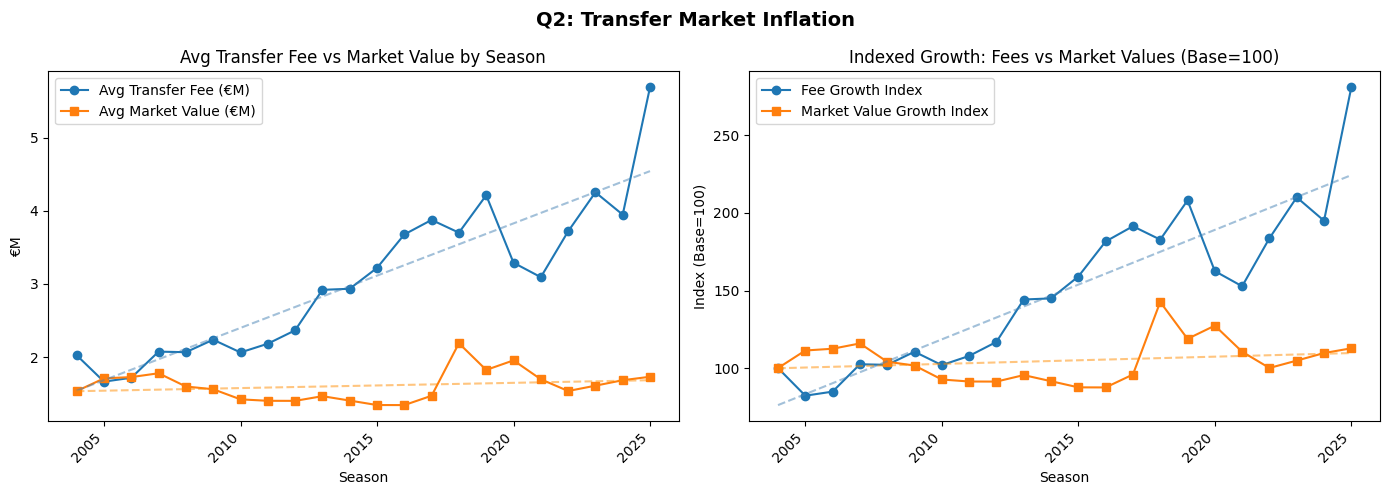

In [47]:
# PLOTS
fig, axes = plt.subplots(1,2, figsize=(14, 5))
# raw values
axes[0].plot(df_inflation['season_year'], df_inflation['avg_fee_m'], marker='o', label='Avg Transfer Fee (€M)')
axes[0].plot(df_inflation['season_year'], df_inflation['avg_value_m'], marker='s', label='Avg Market Value (€M)')
# Trend lines
for col, color in [('avg_fee_m', 'steelblue'), ('avg_value_m', 'darkorange')]:
    z = np.polyfit(df_inflation['season_year'], df_inflation[col], 1)
    p = np.poly1d(z)
    axes[0].plot(df_inflation['season_year'], p(df_inflation['season_year']),'--', color=color, alpha=0.5, linewidth=1.5)
axes[0].set_title("Avg Transfer Fee vs Market Value by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("€M")
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
#  indexed growth + trend lines 
axes[1].plot(df_inflation['season_year'], df_inflation['fee_idx'],   marker='o', label='Fee Growth Index')
axes[1].plot(df_inflation['season_year'], df_inflation['value_idx'], marker='s', label='Market Value Growth Index')
# Trend lines
for col, color in [('fee_idx', 'steelblue'), ('value_idx', 'darkorange')]:
    z = np.polyfit(df_inflation['season_year'], df_inflation[col], 1)
    p = np.poly1d(z)
    axes[1].plot(df_inflation['season_year'], p(df_inflation['season_year']),'--', color=color, alpha=0.5, linewidth=1.5)
axes[1].set_title("Indexed Growth: Fees vs Market Values (Base=100)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Index (Base=100)")
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Q2: Transfer Market Inflation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("q2_transfer_inflation.png")
plt.show()

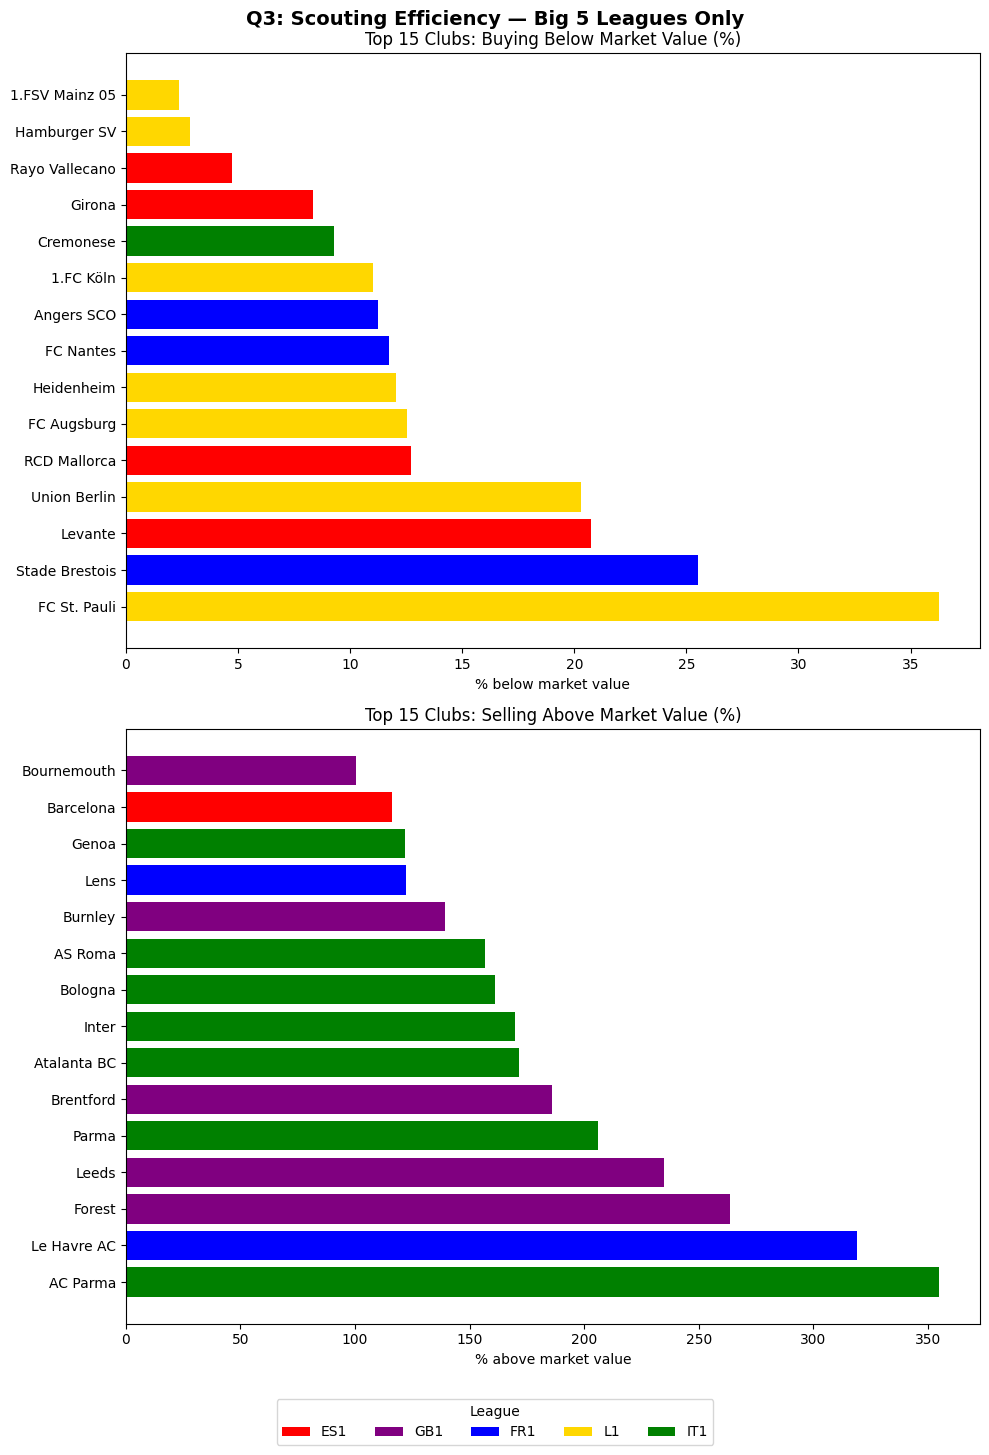

In [24]:
#scouting efficiency
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_transfers    = pd.read_csv("transfer_history/transfer_history.csv")
df_team_details = pd.read_csv("team_details/team_details.csv")

# Filter to Big 5 leagues
top_leagues  = ['ES1', 'GB1', 'FR1', 'L1', 'IT1']
df_top_teams = (df_team_details[df_team_details['competition_id'].isin(top_leagues)][['club_id', 'club_name', 'competition_id']].drop_duplicates())
top_team_ids = df_top_teams['club_id'].tolist()

# Clean transfers
df_fees = df_transfers[df_transfers['transfer_fee'].notna() & (df_transfers['transfer_fee'] > 0) & df_transfers['value_at_transfer'].notna()  & (df_transfers['value_at_transfer'] > 0)].copy()

# Keep transfers where both teams are in Big 5
df_fees = df_transfers[df_transfers['transfer_fee'].notna()& (df_transfers['transfer_fee'] > 0) & df_transfers['value_at_transfer'].notna() & (df_transfers['value_at_transfer'] > 0)].copy()

# Add league for buying club
df_fees = df_fees.merge(df_top_teams.rename(columns={'club_id': 'to_team_id', 'competition_id': 'buy_league'})[['to_team_id', 'buy_league']],on='to_team_id', how='left')

# Add league for selling club
df_fees = df_fees.merge(df_top_teams.rename(columns={'club_id': 'from_team_id', 'competition_id': 'sell_league'})[['from_team_id', 'sell_league']],on='from_team_id', how='left')

# % overpay
df_fees['overpay_pct'] = ((df_fees['transfer_fee'] - df_fees['value_at_transfer']) / df_fees['value_at_transfer'] * 100)

df_buy  = df_fees[df_fees['to_team_id'].isin(top_team_ids)]
df_sell = df_fees[df_fees['from_team_id'].isin(top_team_ids)]
# Min threshold
MIN_TRANSFERS = 10
valid_buyers  = df_fees['to_team_id'].value_counts()
valid_buyers  = valid_buyers[valid_buyers >= MIN_TRANSFERS].index
valid_sellers = df_fees['from_team_id'].value_counts()
valid_sellers = valid_sellers[valid_sellers >= MIN_TRANSFERS].index
df_buy  = df_fees[df_fees['to_team_id'].isin(valid_buyers)]
df_sell = df_fees[df_fees['from_team_id'].isin(valid_sellers)] 

# Aggregations
buy_eff = (
    df_buy.groupby(['to_team_name', 'buy_league'])
    .agg(transfers_in=('player_id', 'count'), avg_buy_overpay_pct=('overpay_pct', 'mean'))
    .reset_index()
    .query('avg_buy_overpay_pct < 0')
)
buy_eff['avg_buy_discount_pct'] = buy_eff['avg_buy_overpay_pct'].abs()
top_buyers = buy_eff.nlargest(15, 'avg_buy_discount_pct')

sell_eff = (
    df_sell.groupby(['from_team_name', 'sell_league'])
    .agg(transfers_out=('player_id', 'count'), avg_sell_premium_pct=('overpay_pct', 'mean'))
    .reset_index()
)
sell_eff = sell_eff[sell_eff['avg_sell_premium_pct'] > 0].nlargest(15, 'avg_sell_premium_pct')

# Plot
league_colors = {'ES1': 'red', 'GB1': 'purple', 'FR1': 'blue', 'L1': 'gold', 'IT1': 'green'}

fig, axes = plt.subplots(2, 1, figsize=(10, 14))

axes[0].barh(top_buyers['to_team_name'], top_buyers['avg_buy_discount_pct'],color=[league_colors.get(l, 'gray') for l in top_buyers['buy_league']])
axes[0].set_title("Top 15 Clubs: Buying Below Market Value (%)")
axes[0].set_xlabel("% below market value")

axes[1].barh(sell_eff['from_team_name'], sell_eff['avg_sell_premium_pct'], color=[league_colors.get(l, 'gray') for l in sell_eff['sell_league']])
axes[1].set_title("Top 15 Clubs: Selling Above Market Value (%)")
axes[1].set_xlabel("% above market value")

legend_elements = [Patch(facecolor=c, label=l) for l, c in league_colors.items()]
fig.legend(handles=legend_elements, title='League', loc='lower center',ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Q3: Scouting Efficiency — Big 5 Leagues Only", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("q3_scouting_efficiency.png", bbox_inches='tight')

C:\Users\laura\AppData\Local\Temp\ipykernel_60152\2777983936.py:7: DtypeWarning: Columns (0: third_club_url, 1: third_club_name, 2: fourth_club_url, 3: fourth_club_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df_profiles = pd.read_csv("player_profiles/player_profiles.csv")


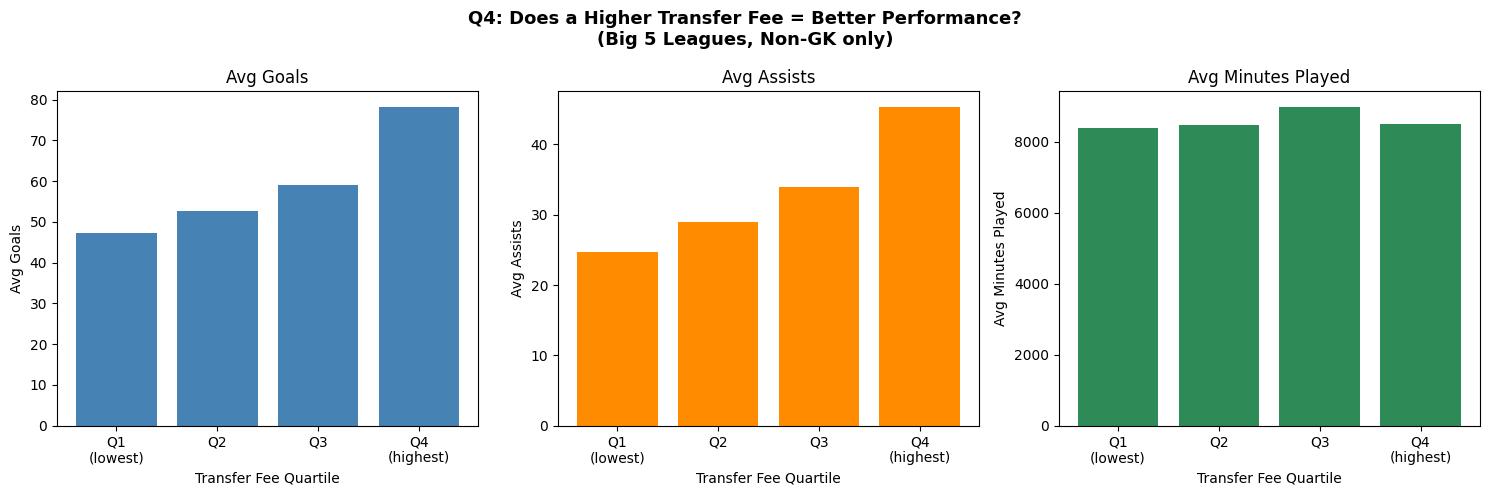

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_transfers = pd.read_csv("transfer_history/transfer_history.csv")
df_team_details = pd.read_csv("team_details/team_details.csv")
df_perf = pd.read_csv("player_performances/player_performances.csv")
df_profiles = pd.read_csv("player_profiles/player_profiles.csv")

# Filter out goalkeepers
non_gk_ids = df_profiles[df_profiles['main_position'] != 'Goalkeeper']['player_id']

# Filter transfers: Big 5 buyers, valid fees
top_leagues  = ['ES1', 'GB1', 'FR1', 'L1', 'IT1']
top_team_ids = df_team_details[df_team_details['competition_id'].isin(top_leagues)]['club_id'].unique()

df_t = df_transfers[df_transfers['to_team_id'].isin(top_team_ids) & df_transfers['transfer_fee'].notna() & (df_transfers['transfer_fee'] > 0) &df_transfers['player_id'].isin(non_gk_ids)][['player_id', 'transfer_fee']].drop_duplicates()

# Aggregate performance per player across all seasons
df_p = (df_perf[df_perf['player_id'].isin(non_gk_ids)].groupby('player_id').agg(total_goals=('goals', 'sum'),total_assists=('assists', 'sum'),total_minutes=('minutes_played', 'sum')).reset_index())

# Merge
df = df_t.merge(df_p, on='player_id', how='inner')

# Quartile buckets
df['fee_quartile'] = pd.qcut(df['transfer_fee'], q=4, labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)'])

# Aggregate by quartile
quartile_agg = (df.groupby('fee_quartile').agg(avg_goals=('total_goals', 'mean'),avg_assists=('total_assists', 'mean'),avg_minutes=('total_minutes', 'mean'),player_count=('player_id', 'count')).reset_index())

# Plot
metrics = ['avg_goals', 'avg_assists', 'avg_minutes']
titles = ['Avg Goals', 'Avg Assists', 'Avg Minutes Played']
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(quartile_agg['fee_quartile'], quartile_agg[metric], color=color)
    ax.set_title(title)
    ax.set_xlabel('Transfer Fee Quartile')
    ax.set_ylabel(title)

plt.suptitle("Q7: Does a Higher Transfer Fee = Better Performance?\n(Big 5 Leagues, Non-GK only)",fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("q7_fee_vs_performance.png", bbox_inches='tight')

C:\Users\laura\AppData\Local\Temp\ipykernel_60152\683365162.py:5: DtypeWarning: Columns (0: third_club_url, 1: third_club_name, 2: fourth_club_url, 3: fourth_club_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df_profiles  = pd.read_csv("player_profiles/player_profiles.csv")
C:\Users\laura\AppData\Local\Temp\ipykernel_60152\683365162.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_grouped, vert=False, labels=country_order, patch_artist=True,


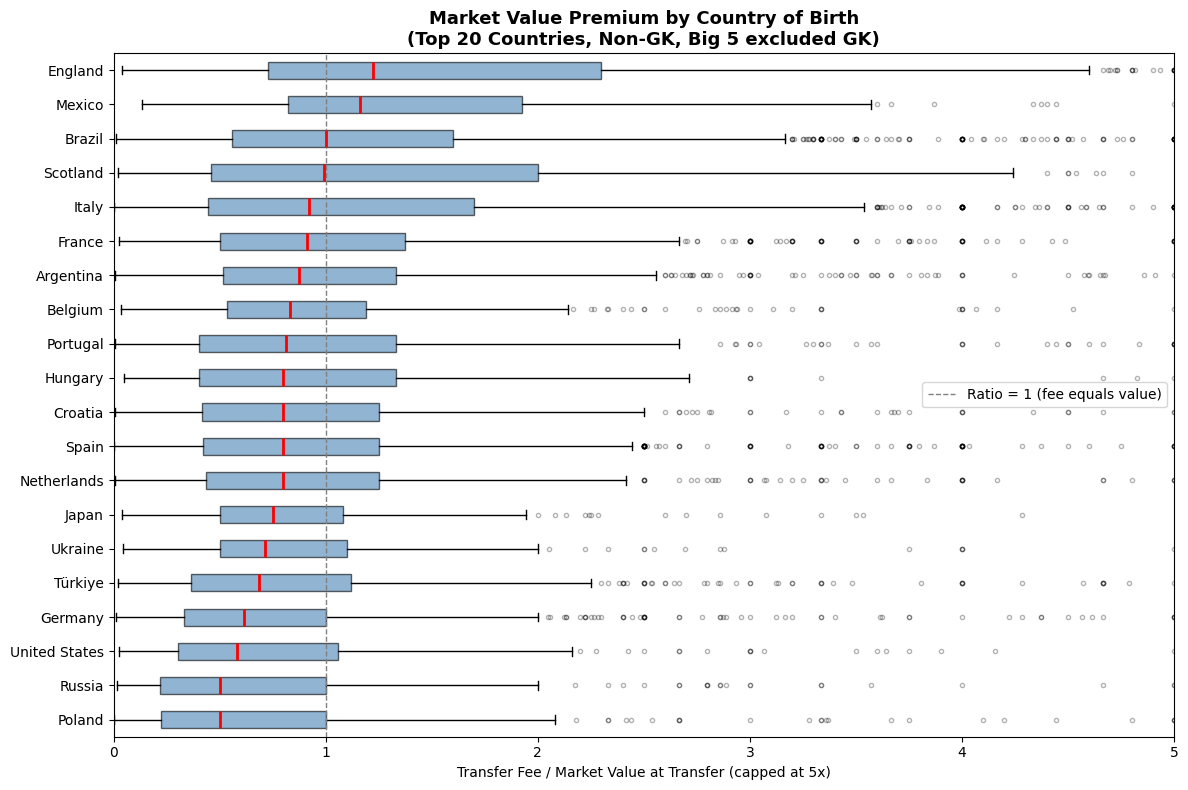

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath(__file__)))
df_transfers = pd.read_csv("transfer_history/transfer_history.csv")
df_profiles  = pd.read_csv("player_profiles/player_profiles.csv")

# Filter out goalkeepers and nulls
df_profiles_clean = df_profiles[(df_profiles['main_position'] != 'Goalkeeper') &(df_profiles['country_of_birth'].notna())]

# Top 20 countries of birth by player count
top_countries = (df_profiles_clean['country_of_birth'].value_counts().head(20).index.tolist())

# Clean transfers
df_t = df_transfers[df_transfers['transfer_fee'].notna()      & (df_transfers['transfer_fee'] > 0) & df_transfers['value_at_transfer'].notna() & (df_transfers['value_at_transfer'] > 0)].copy()

# Compute premium ratio
df_t['premium_ratio'] = df_t['transfer_fee'] / df_t['value_at_transfer']

# Merge with profiles
df = df_t.merge(df_profiles_clean[['player_id', 'country_of_birth']], on='player_id', how='inner')

# Keep only top 20 countries
df = df[df['country_of_birth'].isin(top_countries)]

# Order countries by median premium ratio for clean visual
country_order = (df.groupby('country_of_birth')['premium_ratio'].median().sort_values(ascending=True).index.tolist())

# Plot — box plot shows distribution nicely
fig, ax = plt.subplots(figsize=(12, 8))

data_grouped = [df[df['country_of_birth'] == c]['premium_ratio'].values for c in country_order]
ax.boxplot(data_grouped, vert=False, labels=country_order, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6), medianprops=dict(color='red', linewidth=2),flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, label='Ratio = 1 (fee equals value)')
ax.set_xlabel('Transfer Fee / Market Value at Transfer')
ax.set_title('Market Value Premium by Country of Birth\n(Top 20 Countries, Non-GK, Big 5 excluded GK)',fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
ax.set_xlim(0, 5)
ax.set_xlabel('Transfer Fee / Market Value at Transfer (capped at 5x)')
plt.savefig("q8_nationality_premium.png", bbox_inches='tight')

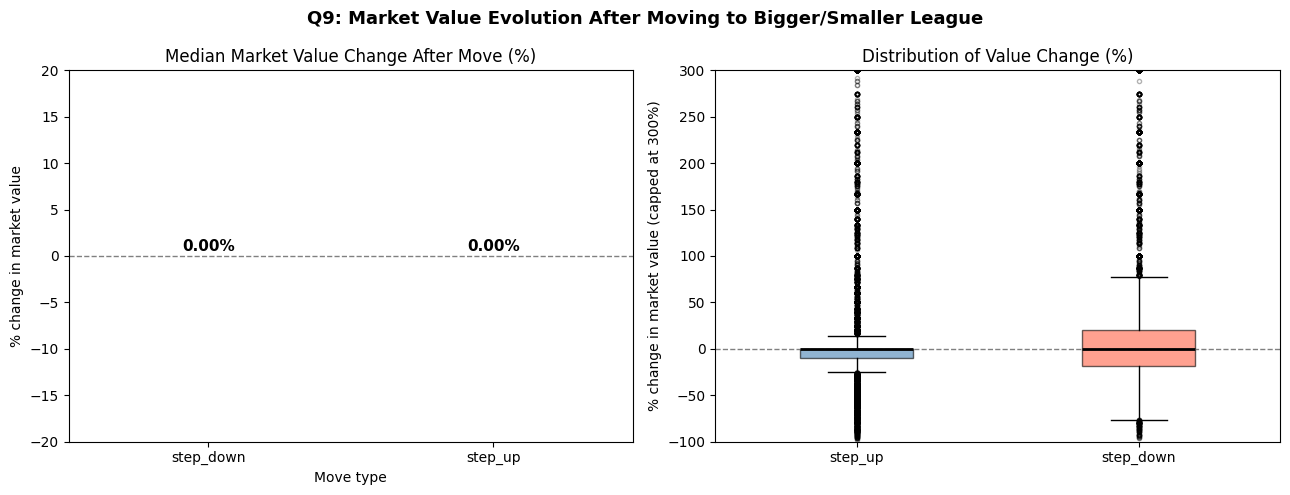

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df_transfers   = pd.read_csv("transfer_history/transfer_history.csv")
df_team_details= pd.read_csv("team_details/team_details.csv")

big5 = ['ES1', 'GB1', 'FR1', 'L1', 'IT1']

# Map club_id -> competition_id
league_map = df_team_details.set_index('club_id')['competition_id'].to_dict()

# Filter valid value rows
df = df_transfers[
    df_transfers['value_at_transfer'].notna() &
    (df_transfers['value_at_transfer'] > 0)
].copy()

# Attach leagues
df['from_league'] = df['from_team_id'].map(league_map)
df['to_league']   = df['to_team_id'].map(league_map)

# Drop rows where either league is unknown
df = df.dropna(subset=['from_league', 'to_league'])

# Classify move type
def classify(row):
    if row['from_league'] not in big5 and row['to_league'] in big5:
        return 'step_up'
    elif row['from_league'] in big5 and row['to_league'] not in big5:
        return 'step_down'
    return None

df['move_type'] = df.apply(classify, axis=1)
df = df[df['move_type'].notna()]

# Sort and get next value per player
df['transfer_date'] = pd.to_datetime(df['transfer_date'])
df = df.sort_values(['player_id', 'transfer_date'])
df['next_value'] = df.groupby('player_id')['value_at_transfer'].shift(-1)

# Filter valid next values
df = df[df['next_value'].notna() & (df['next_value'] > 0)]

# Compute % change
df['value_change_pct'] = (df['next_value'] - df['value_at_transfer']) / df['value_at_transfer'] * 100

# Aggregate
agg = (
    df.groupby('move_type')
    .agg(avg_value_change_pct=('value_change_pct', 'mean'),
         median_value_change_pct=('value_change_pct', 'median'),
         player_count=('player_id', 'count'))
    .reset_index()
)

# Plot
colors = {'step_up': 'steelblue', 'step_down': 'tomato'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — avg % change
axes[0].bar(agg['move_type'], agg['median_value_change_pct'],
            color=[colors[m] for m in agg['move_type']])
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Median Market Value Change After Move (%)')
axes[0].set_ylabel('% change in market value')
axes[0].set_xlabel('Move type')
axes[0].set_ylim(-20, 20) 
for i, row in agg.iterrows():
    axes[0].text(i, row['median_value_change_pct'] + 0.5,
                 f"{row['median_value_change_pct']:.2f}%",
                 ha='center', fontsize=11, fontweight='bold')

# Box plot — distribution
for move, color in colors.items():
    subset = df[df['move_type'] == move]['value_change_pct']
    axes[1].boxplot(subset, positions=[list(colors.keys()).index(move)],
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3),
                    widths=0.4)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['step_up', 'step_down'])
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Value Change (%)')
axes[1].set_ylabel('% change in market value')

axes[1].set_ylim(-100, 300)
axes[1].set_ylabel('% change in market value (capped at 300%)')

plt.suptitle('Q9: Market Value Evolution After Moving to Bigger/Smaller League',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("q9_value_evolution.png", bbox_inches='tight')

C:\Users\laura\AppData\Local\Temp\ipykernel_60152\1126776751.py:4: DtypeWarning: Columns (0: third_club_url, 1: third_club_name, 2: fourth_club_url, 3: fourth_club_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df_profiles = pd.read_csv("player_profiles/player_profiles.csv")
C:\Users\laura\AppData\Local\Temp\ipykernel_60152\1126776751.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_grouped, labels=cap_order, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6), medianprops=dict(color='red', linewidth=2),flierprops=dict(marker='o', markersize=3, alpha=0.3))


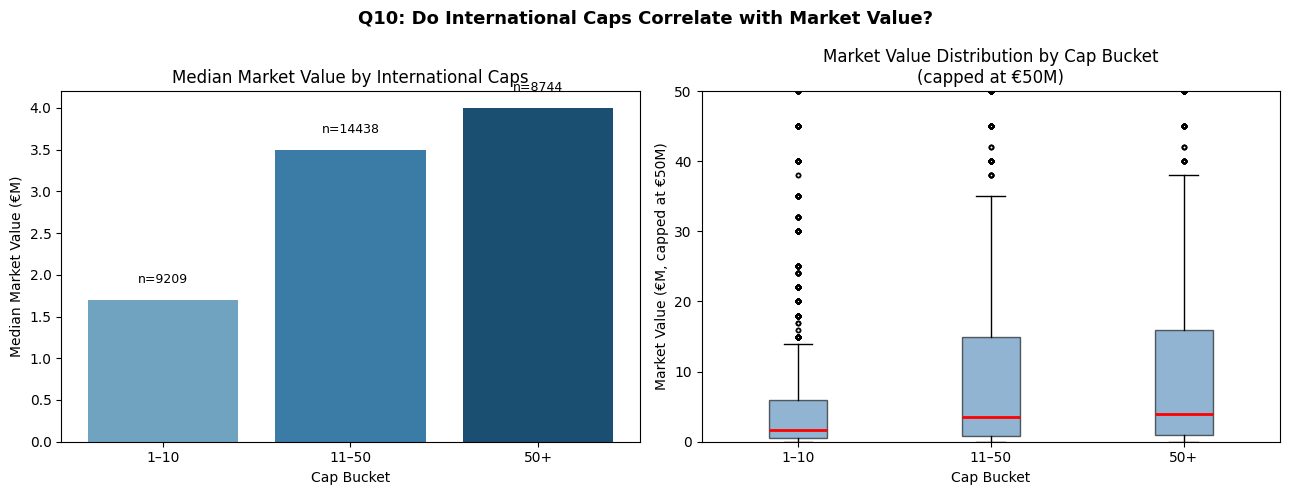

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df_profiles = pd.read_csv("player_profiles/player_profiles.csv")
df_national = pd.read_csv("player_national_performances/player_national_performances.csv")
df_lmv = pd.read_csv("player_latest_market_value/player_latest_market_value.csv")
df_mv = pd.read_csv("player_market_value/player_market_value.csv")

# Active players only
df_active = df_profiles[~df_profiles['current_club_name'].isin(['Retired', '---', '0']) &df_profiles['current_club_name'].notna()][['player_id']]

# Caps — active national players only
df_caps = (df_national[(df_national['career_state'] == 'CURRENT_NATIONAL_PLAYER') &(df_national['matches'] > 0)].groupby('player_id')['matches'].sum().reset_index().rename(columns={'matches': 'total_caps'}))
df_caps = df_caps[df_caps['total_caps'] > 0]

# Market value — latest first, fallback
df_lmv_clean = df_lmv[df_lmv['value'].notna() & (df_lmv['value'] > 0)][['player_id', 'value']].rename(columns={'value': 'lmv'})
df_mv_clean = df_mv[df_mv['value'].notna() & (df_mv['value'] > 0)][['player_id', 'value']].rename(columns={'value': 'mv'})

df_values = df_lmv_clean.merge(df_mv_clean, on='player_id', how='outer')
df_values['market_value'] = df_values['lmv'].combine_first(df_values['mv'])
df_values = df_values[df_values['market_value'].notna()][['player_id', 'market_value']]

# Combine
df = (df_active.merge(df_caps,   on='player_id', how='inner').merge(df_values, on='player_id', how='inner'))

# Cap buckets
def cap_bucket(c):
    if c <= 10:  return '1–10'
    elif c <= 50: return '11–50'
    else: return '50+'

cap_order = ['1–10', '11–50', '50+']
df['cap_bucket'] = pd.Categorical(df['total_caps'].apply(cap_bucket), categories=cap_order, ordered=True)

# Aggregate
agg = (df.groupby('cap_bucket', observed=True).agg(avg_market_value=('market_value', 'mean'),median_market_value=('market_value', 'median'),player_count=('player_id', 'count')).reset_index())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#6fa3bf', '#3a7ca5', '#1b4f72']

# Bar — median market value
axes[0].bar(agg['cap_bucket'], agg['median_market_value'] / 1e6, color=colors)
axes[0].set_title('Median Market Value by International Caps')
axes[0].set_xlabel('Cap Bucket')
axes[0].set_ylabel('Median Market Value (€M)')
for i, row in agg.iterrows():
    axes[0].text(i, row['median_market_value'] / 1e6 + 0.2,f"n={row['player_count']}", ha='center', fontsize=9)

# Box plot — distribution
data_grouped = [df[df['cap_bucket'] == c]['market_value'].values / 1e6 for c in cap_order]
axes[1].boxplot(data_grouped, labels=cap_order, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6), medianprops=dict(color='red', linewidth=2),flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_ylim(0, 50)
axes[1].set_title('Market Value Distribution by Cap Bucket\n(capped at €50M)')
axes[1].set_xlabel('Cap Bucket')
axes[1].set_ylabel('Market Value (€M, capped at €50M)')

plt.suptitle('Q10: Do International Caps Correlate with Market Value?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("q10_caps_vs_market_value.png", bbox_inches='tight')